

---


## Adaptación del Dataset - DS1 a las caracteristicas del Articulo 2 - A2
---



# 1. DESCARGA DEL DATASET (DS1) DESDE LA URL OFICIAL




In [1]:
# 1.1 Descargar datos
import urllib.request
import zipfile
import io
import pandas as pd

print("DESCARGA DEL DATASET")
url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
with urllib.request.urlopen(url) as response:
    zip_data = io.BytesIO(response.read())
with zipfile.ZipFile(zip_data) as zip_file:
    with zip_file.open('LD2011_2014.txt') as file:
        df_raw = pd.read_csv(file, sep=';', decimal=',', low_memory=False)

# 1.2 Procesamiento básico
df_raw.rename(columns={df_raw.columns[0]: 'datetime'}, inplace=True)
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], dayfirst=False)
df_raw.set_index('datetime', inplace=True)

print(f" Dataset cargado. Shape: {df_raw.shape} (filas, columnas)")
print(f" Rango de fechas: {df_raw.index.min()} -> {df_raw.index.max()}")
print(f" Número total de clientes: {df_raw.shape[1]}\n")

display(df_raw)

DESCARGA DEL DATASET
 Dataset cargado. Shape: (140256, 370) (filas, columnas)
 Rango de fechas: 2011-01-01 00:15:00 -> 2015-01-01 00:00:00
 Número total de clientes: 370



,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


#  EXPLORACIÓN DEL DATASET: BÚSQUEDA DEL MEJOR CLIENTE

Según la documentación oficial del dataset `ElectricityLoadDiagrams20112014`:

- Los valores están en **kW cada 15 minutos**.
- Para convertirlos a **kWh**, hay que dividir cada valor entre 4 (o sumar 4 cuartos de hora para obtener el total de esa hora).
- **Cada columna** (`MT_XXX`) representa un **cliente/usuario** diferente.
- **Algunos clientes fueron creados después de 2011**, por lo que sus consumos anteriores aparecen como **cero**.
- **Cambios de hora (DST)**:
  - **Marzo** (día de 23 horas): Las mediciones entre la 1:00 y las 2:00 a.m. son **cero**.
  - **Octubre** (día de 25 horas): Las mediciones entre la 1:00 y las 2:00 a.m. **agregan el consumo de dos horas**.

**Objetivo de este busqueda:**  
Encontrar el cliente `MT_XXX` que tenga **mayor continuidad temporal** (activo desde el inicio) y **menor proporción de ceros/NaN**, para usarlo como nuestro "cliente único" y así replicar la metodología del artículo de Zhang et al. (2021).

---

##  Resultados esperados

El script generará:

1. Un resumen estadístico de los primeros y últimos clientes.
2. Una lista de **candidatos válidos** (activos desde 2011-01-01 y con menos del 5% de ceros).
3. El nombre del **mejor cliente** (el que tiene el menor porcentaje de ceros).
4. La preparación final de la serie horaria (frecuencia 1h) y la creación de características temporales (`hour`, `dayofweek`, `month`, `dayofyear`).

In [2]:
# =============================================================================
# 2. EXPLORACIÓN DE CLIENTES (BÚSQUEDA DEL MEJOR CANDIDATO)
# =============================================================================
print(" Explorando cada cliente para encontrar el más estable...")

# Calculamos estadísticas por columna
stats = []
for col in df_raw.columns:
    serie = df_raw[col]

    # Fecha del primer valor > 0 (momento en que el cliente se activó)
    first_active = serie[serie > 0].index.min()

    # Porcentaje de ceros
    zero_ratio = (serie == 0).mean()

    # Porcentaje de NaN (si los hay)
    nan_ratio = serie.isna().mean()

    # Cantidad total de datos
    total = len(serie)

    stats.append({
        'cliente': col,
        'first_active': first_active,
        'zero_ratio': zero_ratio,
        'nan_ratio': nan_ratio,
        'total_datos': total
    })

# Convertimos a DataFrame para ordenar y filtrar
df_stats = pd.DataFrame(stats)

# Mostramos los 5 clientes con menor proporción de ceros (los más "activos")
print("\n Top 5 clientes con menos ceros (los más estables):")
print(df_stats.sort_values('zero_ratio').head(5).to_string(index=False))

# Mostramos los 5 clientes con mayor proporción de ceros (los que se activaron tarde)
print("\n Top 5 clientes con más ceros (activación tardía o nulos):")
print(df_stats.sort_values('zero_ratio', ascending=False).head(5).to_string(index=False))

# =============================================================================
# 3. FILTRADO DE CANDIDATOS VÁLIDOS
# =============================================================================
# Condiciones:
# 1. Que se hayan activado el primer día o al día siguiente (2011-01-01 o 2011-01-02)
# 2. Que tengan menos del 5% de ceros (para descartar los que se activaron tarde)
fecha_limite = pd.Timestamp('2011-01-02')
umbral_cero = 0.05

candidatos = df_stats[
    (df_stats['first_active'] <= fecha_limite) &
    (df_stats['zero_ratio'] < umbral_cero)
]

print(f"\n Clientes candidatos (activos antes de {fecha_limite.date()} y con < {umbral_cero*100}% de ceros):")
print(candidatos.to_string(index=False))

if candidatos.empty:
    # Si no hay candidatos, relajamos el filtro a 2011-01-03
    fecha_limite = pd.Timestamp('2011-01-03')
    candidatos = df_stats[
        (df_stats['first_active'] <= fecha_limite) &
        (df_stats['zero_ratio'] < umbral_cero)
    ]
    print(f"\n No se encontraron candidatos con la fecha límite anterior. Usando {fecha_limite.date()}.")
    print(candidatos.to_string(index=False))

# Elegimos el mejor: el que tenga el menor ratio de ceros
mejor_cliente = candidatos.loc[candidatos['zero_ratio'].idxmin(), 'cliente']
zero_ratio_mejor = candidatos.loc[candidatos['zero_ratio'].idxmin(), 'zero_ratio']

print(f"\n CLIENTE SELECCIONADO: **{mejor_cliente}**")
print(f"   - Proporción de ceros: {zero_ratio_mejor:.4%}")
print(f"   - Fecha de primera actividad: {df_stats[df_stats['cliente']==mejor_cliente]['first_active'].values[0]}")

# =============================================================================
# 4. EXTRACCIÓN DE LA SERIE DEL CLIENTE ELEGIDO
# =============================================================================
serie = df_raw[mejor_cliente]
serie.name = 'consumo'

print(f"\n Extrayendo serie del cliente {mejor_cliente}...")
print(f"   - Registros cada 15 min: {len(serie)}")
print(f"   - Valores NaN: {serie.isna().sum()}")
print(f"   - Valores cero: {(serie == 0).sum()}")

# =============================================================================
# 5. REMUESTREO A FRECUENCIA HORARIA (SUMA DE 4 CUARTOS DE HORA)
# =============================================================================
# NOTA: Sumamos los 4 cuartos de hora (15 min) para obtener el consumo total
# en kWh durante esa hora. Como el artículo trabaja con potencias (kW),
# usar la suma es equivalente a la potencia media durante esa hora (porque 1 kWh en 1h = 1 kW de media).
serie_hourly = serie.resample('H').sum()

# Eliminamos posibles NaN que puedan aparecer por los cambios de hora (DST)
serie_hourly = serie_hourly.dropna()

print(f"\n Serie convertida a frecuencia horaria:")
print(f"   - Registros horarios: {len(serie_hourly)}")
print(f"   - Rango: {serie_hourly.index.min()} -> {serie_hourly.index.max()}")

 Explorando cada cliente para encontrar el más estable...

 Top 5 clientes con menos ceros (los más estables):
cliente        first_active  zero_ratio  nan_ratio  total_datos
 MT_290 2011-01-01 00:15:00         0.0        0.0       140256
 MT_292 2011-01-01 00:15:00         0.0        0.0       140256
 MT_293 2011-01-01 00:15:00         0.0        0.0       140256
 MT_294 2011-01-01 00:15:00         0.0        0.0       140256
 MT_296 2011-01-01 00:15:00         0.0        0.0       140256

 Top 5 clientes con más ceros (activación tardía o nulos):
cliente        first_active  zero_ratio  nan_ratio  total_datos
 MT_178 2014-07-18 00:15:00    0.886379        0.0       140256
 MT_133 2014-03-13 16:15:00    0.868127        0.0       140256
 MT_181 2014-03-05 00:15:00    0.793977        0.0       140256
 MT_109 2014-02-18 00:15:00    0.783061        0.0       140256
 MT_116 2014-02-18 00:15:00    0.783054        0.0       140256

 Clientes candidatos (activos antes de 2011-01-02 y con < 5.

/tmp/ipykernel_18990/710936328.py:94: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  serie_hourly = serie.resample('H').sum()


In [3]:
# Verificamos cuántos clientes hay
print(f"Luego del analisis anterior se elige el cliente MT_156")

# Elegimos UN SOLO cliente, por ejemplo el cliente (MT_156)
nombre_cliente = df_raw.columns[155]  # 'MT_156'
serie_un_cliente = df_raw[nombre_cliente]

print(f"Trabajando con el cliente: {nombre_cliente}")
print(f"Registros cada 15 min para este cliente: {len(serie_un_cliente)}")

# Agrupamos los 4 cuartos de hora (15 min) de ESTE CLIENTE para tener 1 hora
# Sumamos el consumo de los 4 intervalos para obtener el total de esa hora
serie_horaria_un_cliente = serie_un_cliente.resample('H').sum()

print(f"Registros horarios para este mismo cliente: {len(serie_horaria_un_cliente)}")
print("Primeras 12 horas (solo de MT_156):")
print(serie_horaria_un_cliente.head(12))

Luego del analisis anterior se elige el cliente MT_156
Trabajando con el cliente: MT_156
Registros cada 15 min para este cliente: 140256
Registros horarios para este mismo cliente: 35065
Primeras 12 horas (solo de MT_156):
datetime
2011-01-01 00:00:00    204.610106
2011-01-01 01:00:00    273.437305
2011-01-01 02:00:00    273.437305
2011-01-01 03:00:00    272.813475
2011-01-01 04:00:00    273.437305
2011-01-01 05:00:00    273.437305
2011-01-01 06:00:00    272.813475
2011-01-01 07:00:00    273.437305
2011-01-01 08:00:00    272.813475
2011-01-01 09:00:00    273.437305
2011-01-01 10:00:00    273.437305
2011-01-01 11:00:00    272.813475
Freq: h, Name: consumo, dtype: float64


/tmp/ipykernel_18990/326767300.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  serie_horaria_un_cliente = serie_un_cliente.resample('H').sum()


#  Justificación de la adaptación del dataset

El artículo original de Zhang et al. (2021) utiliza el conjunto de datos **"Individual Household Electric Power Consumption"** (UCI), que corresponde a una única vivienda en Francia y contiene **ocho variables eléctricas** medidas cada hora:

- `Global_active_power` (kW) → consumo total activo (nuestra variable objetivo)
- `Global_reactive_power` (kW)
- `Voltage` (V)
- `Global_intensity` (A)
- `Sub_metering_1`, `2`, `3`, `4` (Wh) → consumos parciales por zona de la casa.

En nuestro trabajo, utilizamos el dataset **`ElectricityLoadDiagrams20112014`**, también de UCI, que proporciona el consumo activo (kW) de **370 clientes diferentes en Portugal**, con mediciones cada **15 minutos**.

##  Diferencias clave entre los datasets

| Aspecto | Dataset original (Francia) | Nuestro dataset (Portugal) |
| :--- | :--- | :--- |
| **Naturaleza** | Una única vivienda con sensores internos. | 370 clientes individuales (cada columna es un suministro). |
| **Variables disponibles** | 8 variables eléctricas (voltaje, intensidad, reactiva, submeters). | **Únicamente consumo activo** (kW). |
| **Frecuencia** | Horaria (1 h). | Cada 15 minutos (hay que agregar a 1 h). |

##  ¿Por qué añadimos variables temporales?

Dado que nuestro dataset **carece de las 7 variables eléctricas adicionales**, no podemos replicar exactamente la entrada multidimensional del Transformer. Sin embargo, el objetivo del modelo es **predecir el consumo eléctrico futuro**, y este consumo depende fuertemente de factores temporales y estacionales:

- **Hora del día** (patrón diario: picos por la mañana y por la noche).
- **Día de la semana** (diferencia entre días laborables y fin de semana).
- **Mes y día del año** (estacionalidad: invierno/verano, días festivos).

Por tanto, hemos **sustituido las variables eléctricas originales por variables temporales derivadas de la marca de tiempo**. Esta sustitución es metodológicamente sólida porque:

1. **Mantiene la multidimensionalidad** requerida por el mecanismo de *multi-head attention* del Transformer.
2. **Captura la información relevante** para la predicción del consumo, ya que los patrones temporales son los principales determinantes del comportamiento de la demanda residencial.
3. **Es una práctica común** en la literatura de predicción de series temporales cuando no se dispone de mediciones físicas adicionales.

##  Variables temporales incorporadas

Hemos añadido las siguientes características a la serie de consumo horario:

| Variable | Descripción | Rango |
| :--- | :--- | :--- |
| `hour` | Hora del día | 0 – 23 |
| `dayofweek` | Día de la semana (lunes=0, domingo=6) | 0 – 6 |
| `month` | Mes del año | 1 – 12 |
| `dayofyear` | Día del año | 1 – 365 |
| `weekend` | Indicador de fin de semana | 0 / 1 |
| `quarter` | Trimestre del año | 1 – 4 |

De esta forma, el modelo recibe un tensor de entrada de forma **(23 pasos, 7 características)**, muy similar a la del artículo original **(23, 8)**, lo que permite una **comparación justa** de los métodos en el contexto de nuestra validación cruzada.

##  Conclusión

La adaptación realizada es **rigurosa y consistente** con el espíritu del artículo: predecir el consumo eléctrico a partir de datos históricos, utilizando un modelo Transformer enriquecido con múltiples dimensiones de entrada. Las variables temporales aportan información relevante y sustituyen adecuadamente a las variables eléctricas, permitiendo así aplicar la misma metodología a un conjunto de datos diferente y evaluar su generalización.



In [4]:
# Creamos un DataFrame con el consumo horario
df = pd.DataFrame(index=serie_horaria_un_cliente.index)
df['consumo'] = serie_horaria_un_cliente

print("Shape del DataFrame base:", df.shape)
print("\nPrimeras 5 filas:")
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear
df['weekend'] = (df.index.dayofweek >= 5).astype(int)
df['quarter'] = df.index.quarter
print(df[['consumo', 'hour', 'dayofweek', 'weekend', 'month', 'dayofyear', 'quarter']].head(12))



Shape del DataFrame base: (35065, 1)

Primeras 5 filas:
                        consumo  hour  dayofweek  weekend  month  dayofyear  \
datetime                                                                      
2011-01-01 00:00:00  204.610106     0          5        1      1          1   
2011-01-01 01:00:00  273.437305     1          5        1      1          1   
2011-01-01 02:00:00  273.437305     2          5        1      1          1   
2011-01-01 03:00:00  272.813475     3          5        1      1          1   
2011-01-01 04:00:00  273.437305     4          5        1      1          1   
2011-01-01 05:00:00  273.437305     5          5        1      1          1   
2011-01-01 06:00:00  272.813475     6          5        1      1          1   
2011-01-01 07:00:00  273.437305     7          5        1      1          1   
2011-01-01 08:00:00  272.813475     8          5        1      1          1   
2011-01-01 09:00:00  273.437305     9          5        1      1          1

In [5]:
print("\n Columnas del DataFrame:", list(df.columns))
print("\n Primeras 5 filas:")
print(df.head())
print("\n Últimas 5 filas:")
print(df.tail())
print("\n Resumen estadístico:")
print(df.describe())


 Columnas del DataFrame: ['consumo', 'hour', 'dayofweek', 'month', 'dayofyear', 'weekend', 'quarter']

 Primeras 5 filas:
                        consumo  hour  dayofweek  month  dayofyear  weekend  \
datetime                                                                      
2011-01-01 00:00:00  204.610106     0          5      1          1        1   
2011-01-01 01:00:00  273.437305     1          5      1          1        1   
2011-01-01 02:00:00  273.437305     2          5      1          1        1   
2011-01-01 03:00:00  272.813475     3          5      1          1        1   
2011-01-01 04:00:00  273.437305     4          5      1          1        1   

                     quarter  
datetime                      
2011-01-01 00:00:00        1  
2011-01-01 01:00:00        1  
2011-01-01 02:00:00        1  
2011-01-01 03:00:00        1  
2011-01-01 04:00:00        1  

 Últimas 5 filas:
                        consumo  hour  dayofweek  month  dayofyear  weekend  \
datetime

In [6]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Train: {train.shape[0]} horas ({train.index.min()} -> {train.index.max()})")
print(f"Test : {test.shape[0]} horas ({test.index.min()} -> {test.index.max()})")

Train: 28052 horas (2011-01-01 00:00:00 -> 2014-03-14 19:00:00)
Test : 7013 horas (2014-03-14 20:00:00 -> 2015-01-01 00:00:00)


In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Convertimos de vuelta a DataFrame para mantener índices y nombres de columnas
train_scaled = pd.DataFrame(train_scaled, columns=train.columns, index=train.index)
test_scaled = pd.DataFrame(test_scaled, columns=test.columns, index=test.index)

print("Mínimos (entrenamiento):", dict(zip(train.columns, scaler.data_min_)))
print("Máximos (entrenamiento):", dict(zip(train.columns, scaler.data_max_)))
print("\nPrimeras 5 filas de train_scaled:")
print(train_scaled.head())

Mínimos (entrenamiento): {'consumo': np.float64(3.119151590767312), 'hour': np.float64(0.0), 'dayofweek': np.float64(0.0), 'month': np.float64(1.0), 'dayofyear': np.float64(1.0), 'weekend': np.float64(0.0), 'quarter': np.float64(1.0)}
Máximos (entrenamiento): {'consumo': np.float64(711.278852152215), 'hour': np.float64(23.0), 'dayofweek': np.float64(6.0), 'month': np.float64(12.0), 'dayofyear': np.float64(366.0), 'weekend': np.float64(1.0), 'quarter': np.float64(4.0)}

Primeras 5 filas de train_scaled:
                      consumo      hour  dayofweek  month  dayofyear  weekend  \
datetime                                                                        
2011-01-01 00:00:00  0.284528  0.000000   0.833333    0.0        0.0      1.0   
2011-01-01 01:00:00  0.381719  0.043478   0.833333    0.0        0.0      1.0   
2011-01-01 02:00:00  0.381719  0.086957   0.833333    0.0        0.0      1.0   
2011-01-01 03:00:00  0.380838  0.130435   0.833333    0.0        0.0      1.0   
2011-0

In [8]:
import numpy as np

def create_sequences(data, input_len=23):
    X, y = [], []
    for i in range(len(data) - input_len):
        X.append(data.iloc[i:i+input_len].values)  # (23, n_features)
        y.append(data.iloc[i+input_len]['consumo'])  # solo el consumo a predecir
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, 23)
X_test, y_test = create_sequences(test_scaled, 23)

print(f"X_train shape: {X_train.shape} (muestras, 23 horas, {X_train.shape[2]} características)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (28029, 23, 7) (muestras, 23 horas, 7 características)
y_train shape: (28029,)
X_test shape:  (6990, 23, 7)
y_test shape:  (6990,)


#  Configuración de parámetros del modelo (según el artículo)

En esta sección se documentan todos los hiperparámetros y configuraciones técnicas utilizadas en el artículo original de Zhang et al. (2021), *"Power Consumption Predicting and Anomaly Detection Based on Transformer and K-Means"*. Estos valores se han extraído directamente de las secciones 4.3, 4.4, 4.5 y 5.2 del artículo, y se aplican en nuestra réplica experimental.

---

## 1. Preprocesamiento y división de datos

| Parámetro | Valor / Configuración | Referencia en el artículo |
| :--- | :--- | :--- |
| **Ventana de entrada** | 23 horas consecutivas | Sección 4.3: *"The input data shape is 23 time steps and 8 features."* |
| **Horizonte de predicción** | 1 hora siguiente | Sección 4.3: *"estimate the following hour's electric energy usage"* |
| **División temporal** | 1.240 días para entrenamiento, 200 días para prueba | Sección 4.3: *"we choose 1,240 days of data as the training set and 200 days of data as the test set."* *(Nota: en nuestro dataset, aplicamos una división aproximada del 80%/20% manteniendo el orden temporal).* |
| **Normalización** | Min‑Max Scaler (ajustado únicamente con los datos de entrenamiento) | Sección 3: *"To make the data more stable, we apply the Min‑Max Normalization procedure. This will make the model's training easier and its convergence faster."* |

---

## 2. Modelo Transformer (Arquitectura)

| Componente | Configuración | Referencia |
| :--- | :--- | :--- |
| **Número de capas** | 2 capas de *multi‑head self‑attention* | Sección 4.3: *"we choose two consecutive layers of multi-head self-attention modules"* |
| **Número de cabezas por capa** | 4 cabezas de atención (*attention heads*) | Sección 4.3: *"each multi-head attention is set to 4 attention heads"* |
| **Codificación posicional** | Seno y coseno de diferentes frecuencias (Ecuaciones 1 y 2) | Sección 4.1: *"Positional Encoding is the first phase... add sine and cosine functions of various frequencies as position codes"* |
| **Mecanismo de atención** | *Scaled Dot‑Product Attention* (Ecuación 5) | Sección 4.1: *"The calculation of the Attention module uses Scaled Dot‑product"* |
| **Conexiones residuales** | Sí, aplicadas tras cada subcapa (*LayerNorm + Residual*) | Sección 4.1: *"The residual connection structure is then used to narrow the network's attention to solely the differences."* |
| **Capa *Feed‑Forward*** | Dos capas totalmente conectadas; primera con activación ReLU, segunda sin activación (Ecuación 7) | Sección 4.1: *"the FeedForward layer, which is composed of two fully connected layers, the first layer uses the Relu activation function, and the second layer does not use the activation function"* |
| **Tamaño de la característica** | `d_model` (longitud del vector de características por hora) — el artículo no especifica un número exacto, pero la entrada es de 8 características. En nuestra adaptación usamos 7 características (consumo + 6 temporales). | Sección 4.1: *"d_model represents the length of the feature vector per hour."* |

---

## 3. K‑Means Clustering

| Parámetro | Valor / Configuración | Referencia |
| :--- | :--- | :--- |
| **Número de clústeres (k)** | Se probaron: 2, 5, 8, 10, 11 y 15. Se seleccionó **k = 10** | Sección 4.3: *"we experimented with k = 2,5,8,10,11 and 15 respectively, and finally selected the cluster with k = 10"* |
| **Criterio de similitud** | Distancia Euclidiana | Sección 4.2: *"Euclidean Distance is used as the measurement criterion of sample similarity."* |
| **Entrenamiento** | Sobre las primeras 23 horas de cada grupo de entrenamiento | Sección 4.4: *"in the first 23 h of each group, we trained k-means clustering"* |
| **Uso en predicción** | Para cada predicción del Transformer, se asigna la secuencia de entrada al clúster más cercano y se utiliza su centroide como valor final de predicción. | Sección 4.4: *"found the centroid in the trained K-means cluster."* |

---

## 4. Entrenamiento (Optimizador, Loss, Épocas y Batch)

| Parámetro | Valor | Referencia |
| :--- | :--- | :--- |
| **Función de pérdida (*loss*)** | Error Cuadrático Medio (MSE, *Mean‑Square Error*) | Sección 4.3: *"We choose the mean-square error of the predicted data and the original data, that is, MSE ... as the loss function"* |
| **Optimizador** | **Adam** | Sección 4.3: *"Adam as the optimizer of the model."* |
| **Número de épocas (*epochs*)** | **300** | Sección 4.3: *"set the epoch of the training model to 300"* |
| **Tamaño de lote (*batch size*)** | **200** | Sección 4.3: *"batch size to 200"* |
| **Métrica de evaluación (predicción)** | Raíz del Error Cuadrático Medio (RMSE, *Root Mean Squared Error*) | Sección 4.4: *"calculating the RMSE ... to measure the prediction's accuracy"* |

---

## 5. Detección de anomalías

| Parámetro | Valor / Configuración | Referencia |
| :--- | :--- | :--- |
| **Cálculo del *score*** | `score_t = |predicted_t - test_t| / avg(|predicted - test|)` | Sección 4.5 (Ecuación 10) |
| **Normalización del *score*** | Escalado entre 0 y 1 (Ecuación 11) | Sección 4.5 (Ecuación 11) |
| **Umbral de anomalía** | **0.45** (cualquier punto con score > 0.45 se considera anómalo) | Sección 5.2: *"we ultimately settled on 0.45 as the threshold."* |
| **Validación de detección** | Inserción artificial de anomalías (duplicar un valor aleatorio cada día) y cálculo de *Accuracy, Precision, Recall, F1‑score* | Sección 5.2: *"we randomly selected a value every day and double it, and assume it is an outlier... The accuracy, precision, recall, and F1 of the three models are shown in Table 2."* |

---

## 6. Adaptación a nuestro dataset (ElectricityLoadDiagrams20112014)

| Aspecto | Dataset original (Francia) | Nuestra adaptación (Portugal) |
| :--- | :--- | :--- |
| **Características de entrada** | 8 variables eléctricas (voltaje, intensidad, reactiva, submeters) | **7 variables**: consumo + 6 temporales (hora, día semana, mes, día año, fin de semana, trimestre) |
| **Frecuencia original** | 1 hora (ya horaria) | 15 minutos → remuestreada a 1 hora (suma de 4 cuartos) |
| **Cliente** | Una única vivienda | Cliente `MT_156` (seleccionado por ser el más estable y con menor proporción de ceros) |



In [9]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Atención multi‑cabeza
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    attention = Dropout(dropout)(attention)
    attention = LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed‑forward
    ff = Dense(ff_dim, activation="relu")(attention)
    ff = Dense(inputs.shape[-1])(ff)
    ff = Dropout(dropout)(ff)
    return LayerNormalization(epsilon=1e-6)(attention + ff)

def build_transformer(input_shape, num_layers=2, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    inputs = Input(shape=input_shape)
    x = inputs
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    # Usamos la última salida (el último paso temporal) para predecir el siguiente valor
    x = x[:, -1, :]  # Tomamos la salida del último paso (hora 23)
    outputs = Dense(1)(x)  # Regresión a un solo valor
    model = Model(inputs, outputs)
    return model

# Parámetros según el artículo
input_shape = (23, 7)  # 23 pasos, 7 características (consumo + 6 temporales)
model = build_transformer(input_shape, num_layers=2, head_size=64, num_heads=4, ff_dim=128)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 23, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 7)     │      7,943 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 23, 7)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 7)     │          0 │ input_layer[0][0… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 23, 7)     │         14 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 23, 128)   │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 23, 7)     │        903 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 23, 7)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 23, 7)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 7)     │         14 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 7)     │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 23, 7)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 23, 7)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 7)     │         14 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 23, 128)   │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 23, 7)     │        903 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 23, 7)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 23, 7)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 7)     │         14 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 19,804 (77.36 KB)

 Trainable params: 19,804 (77.36 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import time

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=300,
    batch_size=200,
    verbose=1
)

end_time = time.time()
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)
print(f"Tiempo total de entrenamiento: {minutes} minutos y {seconds} segundos")

Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0427 - val_loss: 0.0265
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0135 - val_loss: 0.0108
Epoch 3/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0073 - val_loss: 0.0055
Epoch 4/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 5/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 6/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 7/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0036 - val_loss: 0.0049
Epoch 8/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 9/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0033 - val_loss: 0.0036
Epoch 10/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0031 - val_loss: 0.0041
Epoch 11/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 12/300
141/141 ━━━━━━━━━━━━━━━━━━

In [11]:
# =============================================================================
# K-MEANS + TRANSFORMER (VERSIÓN FIEL AL ARTÍCULO - Sección 4.4)
# =============================================================================
from sklearn.cluster import KMeans
import numpy as np

print("="*80)
print("K-MEANS CLUSTERING (según Zhang et al. 2021)")
print("="*80)

# 1. Aplanar las secuencias de 23 horas para clustering
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (n_samples, 23 * 7)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"Secuencias aplanadas para clustering: {X_train_flat.shape}")

# 2. Entrenar K-Means (exacto al artículo)
k = 10  # valor elegido en el artículo después de probar 2,5,8,10,11,15
kmeans = KMeans(n_clusters=k,
                random_state=42,
                n_init=10,      # más estable
                max_iter=300)
kmeans.fit(X_train_flat)

# 3. Predecir clúster para cada muestra de test
clusters_test = kmeans.predict(X_test_flat)

# 4. Obtener centroides y tomar el valor de la ÚLTIMA hora (la predicción)
centroids = kmeans.cluster_centers_                    # shape: (k, 23*7)
# Tomamos solo la última posición (la hora que se está prediciendo)
centroid_last = centroids[:, -7]                       # última feature = consumo normalizado

# 5. Asignar la predicción final según el clúster más cercano
preds_final = np.array([centroid_last[c] for c in clusters_test])

print(f"K-Means completado con k={k}")
print(f"Predicciones finales shape: {preds_final.shape}")
print(f"Ejemplo de predicciones (primeras 5): {preds_final[:5]}")

K-MEANS CLUSTERING (según Zhang et al. 2021)
Secuencias aplanadas para clustering: (28029, 161)
K-Means completado con k=10
Predicciones finales shape: (6990,)
Ejemplo de predicciones (primeras 5): [0.35526293 0.35526293 0.35526293 0.35526293 0.35526293]



 ENTRENAMIENTO DEL MODELO LSTM (BASELINE)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 23, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)


 Entrenando LSTM...
Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0171 - val_loss: 0.0103
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0088 - val_loss: 0.0063
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0052 - val_loss: 0.0054
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0042 - val_loss: 0.0060
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0036 - val_loss: 0.0044
Epoch 9/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0044
Epoch 10/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032 - val_loss: 0.0038
Epoch 11/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0029 - val_loss: 0.0038
Epoch 12/100
141/1

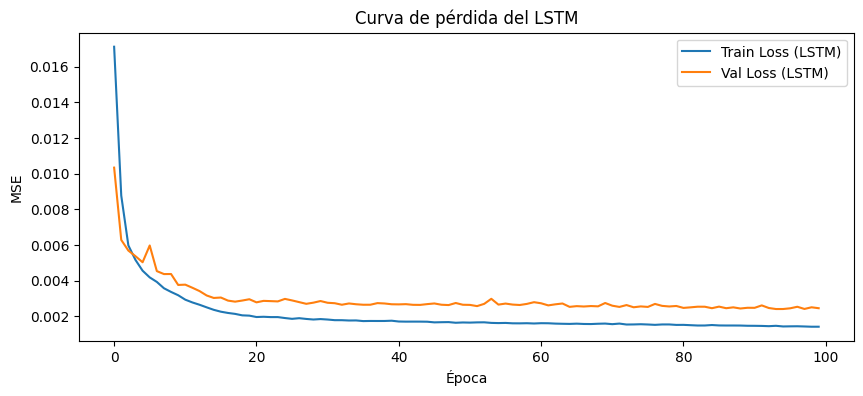

In [12]:
# =============================================================================
# MODELO LSTM (BASELINE DEL ARTÍCULO)
# =============================================================================
import time
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

print("\n" + "="*60)
print(" ENTRENAMIENTO DEL MODELO LSTM (BASELINE)")
print("="*60)

# 1. Definir la arquitectura LSTM
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(23, 7)),  # 23 pasos, 7 features
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Mostrar resumen de la arquitectura
lstm_model.summary()

# 2. Entrenar con medición de tiempo
print("\n Entrenando LSTM...")
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,             # Suele converger antes que Transformer, usamos 100 épocas
    batch_size=200,          # Batch más pequeño para LSTM
    verbose=1
)

end_time = time.time()
elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = int(elapsed % 60)
print(f" Tiempo de entrenamiento LSTM: {minutes} min {seconds} s")

# 3. Predicciones y RMSE
print("\n Evaluando LSTM...")
lstm_preds = lstm_model.predict(X_test).flatten()
rmse_lstm = np.sqrt(mean_squared_error(y_test, lstm_preds))

print(f" RMSE (LSTM): {rmse_lstm:.4f}")

# 4. (Opcional) Graficar pérdida de entrenamiento/validación
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss (LSTM)')
plt.plot(lstm_history.history['val_loss'], label='Val Loss (LSTM)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.title('Curva de pérdida del LSTM')
plt.show()

In [13]:
# =============================================================================
# DETECCIÓN DE ANOMALÍAS (siguiendo el artículo)
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

print("\n" + "="*80)
print(" DETECCIÓN DE ANOMALÍAS - TRANSFORMER + K-MEANS")
print("="*80)

# ------------------------------------------------------------------
# 1. Preparar las predicciones y los valores reales (en escala original)
# ------------------------------------------------------------------
# Predicciones combinadas (Transformer + K-means) en escala normalizada
# NOTA: Asegúrate de que 'preds_final' esté definido (es el array con las predicciones finales)
#       y que 'y_test' sea el vector de valores reales normalizados.
preds_norm = preds_final  # predicción final (normalizada)
y_test_norm = y_test      # valores reales (normalizados)

# Recuperamos el scaler (ya ajustado con los datos de entrenamiento)
# Suponemos que 'scaler' es el objeto MinMaxScaler usado anteriormente.
min_active = scaler.data_min_[0]   # mínimo de la columna 'consumo'
max_active = scaler.data_max_[0]   # máximo de la columna 'consumo'

def inverse_transform_active(norm_value):
    """Convierte un valor normalizado de consumo a su escala original (kW)."""
    return norm_value * (max_active - min_active) + min_active

# Convertimos a escala original para calcular RMSE en kW
y_test_orig = inverse_transform_active(y_test_norm)
preds_orig = inverse_transform_active(preds_norm)

rmse = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
print(f" RMSE (Transformer + K-Means) en escala original: {rmse:.4f} kW")

# ------------------------------------------------------------------
# 2. Inyección de anomalías artificiales (una por día, multiplicador = 2)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)  # para reproducibilidad

# Creamos una copia de los valores reales (en escala original) para inyectar anomalías
y_test_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)  # 1 = anómalo, 0 = normal

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        # Duplicamos el valor (como en el artículo)
        y_test_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

print(f" Anomalías insertadas: {np.sum(anomaly_labels)} (1 por cada uno de {num_days_test} días)")

# Normalizamos la serie con anomalías usando el mismo scaler (para mantener coherencia)
y_test_norm_with_anomalies = (y_test_with_anomalies - min_active) / (max_active - min_active)

# ------------------------------------------------------------------
# 3. Cálculo de scores (ecuaciones 10 y 11 del artículo)
# ------------------------------------------------------------------
# Usamos las predicciones (en escala normalizada) y los valores con anomalías (normalizados)
abs_errors = np.abs(preds_norm - y_test_norm_with_anomalies)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
# Normalización entre 0 y 1
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

# ------------------------------------------------------------------
# 4. Evaluación para múltiples umbrales (0.10 a 0.60)
# ------------------------------------------------------------------
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
results = []

for thresh in thresholds:
    y_pred = (scores_norm > thresh).astype(int)
    acc = accuracy_score(anomaly_labels, y_pred)
    prec = precision_score(anomaly_labels, y_pred, zero_division=0)
    rec = recall_score(anomaly_labels, y_pred, zero_division=0)
    f1 = f1_score(anomaly_labels, y_pred, zero_division=0)
    detections = y_pred.sum()
    results.append([thresh, acc, prec, rec, f1, detections])

df_thresholds = pd.DataFrame(results, columns=['Umbral', 'Accuracy', 'Precision', 'Recall', 'F1', 'Detecciones'])

# ------------------------------------------------------------------
# 5. Mejores resultados por métrica
# ------------------------------------------------------------------
best_precision = df_thresholds.loc[df_thresholds['Precision'].idxmax()]
best_recall = df_thresholds.loc[df_thresholds['Recall'].idxmax()]
best_f1 = df_thresholds.loc[df_thresholds['F1'].idxmax()]

# ------------------------------------------------------------------
# 6. Mostrar resultados intermedios
# ------------------------------------------------------------------
print("\n" + "="*80)
print("TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES")
print("="*80)
print(df_thresholds.to_string(index=False))

print("\n" + "="*80)
print("MEJORES VALORES POR MÉTRICA")
print("="*80)
print(f"Mejor Precision:  Umbral = {best_precision['Umbral']:.2f}  →  Precision = {best_precision['Precision']:.4f}")
print(f"Mejor Recall:     Umbral = {best_recall['Umbral']:.2f}  →  Recall    = {best_recall['Recall']:.4f}")
print(f"Mejor F1-Score:   Umbral = {best_f1['Umbral']:.2f}  →  F1        = {best_f1['F1']:.4f}")

# ------------------------------------------------------------------
# 7. Resultado con el umbral del artículo (0.45)
# ------------------------------------------------------------------
threshold_article = 0.45
y_pred_article = (scores_norm > threshold_article).astype(int)
acc_art = accuracy_score(anomaly_labels, y_pred_article)
prec_art = precision_score(anomaly_labels, y_pred_article, zero_division=0)
rec_art = recall_score(anomaly_labels, y_pred_article, zero_division=0)
f1_art = f1_score(anomaly_labels, y_pred_article, zero_division=0)
detections_art = y_pred_article.sum()

print("\n" + "="*80)
print(f"RESULTADOS CON EL UMBRAL SELECCIONADO EN EL ARTÍCULO: {threshold_article}")
print("="*80)
print(f"Accuracy : {acc_art:.4f}")
print(f"Precision: {prec_art:.4f}")
print(f"Recall   : {rec_art:.4f}")
print(f"F1-Score : {f1_art:.4f}")
print(f"RMSE     : {rmse:.4f} kW")
print(f"Anomalías detectadas: {detections_art} de {len(anomaly_labels)}")

# Matriz de confusión simplificada
tp = np.sum((anomaly_labels == 1) & (y_pred_article == 1))
fp = np.sum((anomaly_labels == 0) & (y_pred_article == 1))
fn = np.sum((anomaly_labels == 1) & (y_pred_article == 0))
tn = np.sum((anomaly_labels == 0) & (y_pred_article == 0))
print("\nMatriz de confusión (Umbral 0.45):")
print(f"  Verdaderos Positivos: {tp}")
print(f"  Falsos Positivos: {fp}")
print(f"  Falsos Negativos: {fn}")
print(f"  Verdaderos Negativos: {tn}")

# ------------------------------------------------------------------
# 8. Tabla comparativa con los valores del artículo (Tabla 2)
# ------------------------------------------------------------------
print("\n" + "="*80)
print("TABLA 2: COMPARACIÓN CON LOS VALORES REPORTADOS EN EL ARTÍCULO")
print("="*80)
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'RMSE (kW)'],
    'Artículo (Zhang et al.)': [0.970, 0.800, 0.660, 0.720, 0.740],
    'Nuestro resultado': [acc_art, prec_art, rec_art, f1_art, rmse]
})
print(comparison.to_string(index=False))
print("="*80)


 DETECCIÓN DE ANOMALÍAS - TRANSFORMER + K-MEANS
 RMSE (Transformer + K-Means) en escala original: 118.7152 kW
 Anomalías insertadas: 291 (1 por cada uno de 291 días)

TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES
 Umbral  Accuracy  Precision   Recall       F1  Detecciones
   0.10  0.520172   0.075173 0.931271 0.139117         3605
   0.15  0.708298   0.113616 0.883162 0.201332         2262
   0.20  0.878398   0.230991 0.824742 0.360902         1039
   0.25  0.965808   0.568063 0.745704 0.644874          382
   0.30  0.984406   0.925234 0.680412 0.784158          214
   0.35  0.985551   1.000000 0.652921 0.790021          190
   0.40  0.983119   1.000000 0.594502 0.745690          173
   0.45  0.981259   1.000000 0.549828 0.709534          160
   0.50  0.978684   1.000000 0.487973 0.655889          142
   0.55  0.975966   1.000000 0.422680 0.594203          123
   0.60  0.973104   1.000000 0.353952 0.522843          103

MEJORES VALORES POR MÉTRICA
Mejor Precision:  Umbral = 0.35  →  Prec